# Proyek Analisis Data: Bike Sharing Dataset
- **Nama:** Muhammad Fachreza Aldava Sinaga
- **Email:** muhammadfachreza961@gmail.com
- **Username Dicoding:** muhammad_fachreza_aldava_sinaga_smfD

## Menentukan Pertanyaan Bisnis

**SMART Question** adalah sebuah framework untuk merumuskan pertanyaan secara terstruktur agar memeperoleh informasi yang mendalam.

* **Spesific (Spesifik)**
  * Pertanyaan harus jelas, fokus pada sebuah topik tertentu, dan tidak bermakna ganda. Hindari pertanyaan yang terlalu luas.
    * Salah: Bagaimana cara meningkatkan penjualan?
    * Benar: Faktor apa saja yang memengaruhi penurunan penjualan produk kategori elektronik di wilayah Jakarta selama kuartal terakhir?
* **Measurable (Terukur)**
  * Pertanyaan harus bisa dijawab dengan angka atau matrix yang konkret, harus tahu apa yang akan dihitung.
    * Salah: Apakah pelanggan senang dengan layanan kita?
    * Benar: Berapa skor rata-rata Customer Satisfaction untuk layanan purna jual bulan ini dibandingkan bulan lalu?
* **Action-Oriented (Berorientasi Aksi)**
  * Hasil dari pertanyaan harus bisa memberikan arahan untuk melakukan tindakan nyata. Jika pertanyaan terjawab, stakeholder harus tahu apa langkah selanjutnya.
    * Salah: Mengapa orang suka berbelanja?
    * Benar: Fitur apa pada aplikasi yang paling sering digunakan sebelum pengguna memutuskan untuk melakukan checkout?
* **Relevant (Relevan)**
  * Hasil dari pertanyaan harus sejalan dengan tujuan utama bisnis atau masalah yang sedang dihadapi.
    * Salah: Menanyakan tentang stok gudang saat masalah utamanya adalah efektivitas kampanye media sosial.
    * Benar: Apakah kampanye iklan di Instagram memberikan Return on Ad Spend (ROAS) yang lebih tinggi dibandingkan iklan di TikTok?
* **Time-bound (Terikat Waktu)**
  * Pertanyaan harus ada batasan waktu yang jelas agar analisis memiliki konteks yang tepat.
    * Salah: Berapa banyak pengguna baru kita?
    * Benar: Berapa tingkat pertumbuhan pengguna baru secara bulanan (Month-over-Month) sepanjang tahun 2025?

**Contoh pertanyaan bisnis yang memenuhi seluruh elemen SMART**

***"Faktor apa saja yang memengaruhi penurunan conversion rate pada pengguna aplikasi Android di wilayah Jabodetabek sebesar 5% selama periode Flash Sale Maret 2026?"***

Keterangan:

- **Specific**: Fokus pada "penurunan conversion rate" untuk "aplikasi Android" di "Jabodetabek". Bukan sekadar penjualan turun.
- **Measurable**: Ada angka konkret yang ingin dianalisis, yaitu penurunan sebesar "5%".
- **Action-Oriented**: Dengan mengetahui faktor penyebabnya misalnya bug pada versi Android tertentu atau kendala logistik di Jabodetabek, tim bisa langsung melakukan perbaikan teknis atau operasional.
- **Relevant**: Penurunan konversi saat Flash Sale adalah masalah kritis bagi bisnis retail/e-commerce.
- **Time-bound**: Dibatasi pada periode spesifik "Flash Sale Maret 2026".

- **Pertanyaan 1:** Bagaimana pengaruh kondisi cuaca terhadap jumlah penyewaan sepeda per hari selama tahun 2011–2012?

- **Pertanyaan 2:** "Pada jam berapa terjadi puncak penyewaan sepeda berdasarkan rata-rata jumlah penyewaan antara hari kerja (weekday) dan hari libur (weekend) selama 2011–2012?"

## Import Semua Packages/Library yang Digunakan

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style='whitegrid')

## Data Wrangling

### Gathering Data

#### Load df ...

In [3]:
day_df = pd.read_csv('day.csv')
hour_df = pd.read_csv('hour.csv')

day_df.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


### Assessing Data

#### Identifying ... problem

In [4]:
day_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    object 
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        731 non-null    float64
 10  atemp       731 non-null    float64
 11  hum         731 non-null    float64
 12  windspeed   731 non-null    float64
 13  casual      731 non-null    int64  
 14  registered  731 non-null    int64  
 15  cnt         731 non-null    int64  
dtypes: float64(4), int64(11), object(1)
memory usage: 91.5+ KB


In [5]:
hour_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     17379 non-null  int64  
 1   dteday      17379 non-null  object 
 2   season      17379 non-null  int64  
 3   yr          17379 non-null  int64  
 4   mnth        17379 non-null  int64  
 5   hr          17379 non-null  int64  
 6   holiday     17379 non-null  int64  
 7   weekday     17379 non-null  int64  
 8   workingday  17379 non-null  int64  
 9   weathersit  17379 non-null  int64  
 10  temp        17379 non-null  float64
 11  atemp       17379 non-null  float64
 12  hum         17379 non-null  float64
 13  windspeed   17379 non-null  float64
 14  casual      17379 non-null  int64  
 15  registered  17379 non-null  int64  
 16  cnt         17379 non-null  int64  
dtypes: float64(4), int64(12), object(1)
memory usage: 2.3+ MB


In [ ]:
day_df.describe()

,instant,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
mean,366.000000,2.496580,0.500684,6.519836,0.028728,2.997264,0.683995,1.395349,0.495385,0.474354,0.627894,0.190486,848.176471,3656.172367,4504.348837
std,211.165812,1.110807,0.500342,3.451913,0.167155,2.004787,0.465233,0.544894,0.183051,0.162961,0.142429,0.077498,686.622488,1560.256377,1937.211452
min,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.059130,0.079070,0.000000,0.022392,2.000000,20.000000,22.000000
25%,183.500000,2.000000,0.000000,4.000000,0.000000,1.000000,0.000000,1.000000,0.337083,0.337842,0.520000,0.134950,315.500000,2497.000000,3152.000000
50%,366.000000,3.000000,1.000000,7.000000,0.000000,3.000000,1.000000,1.000000,0.498333,0.486733,0.626667,0.180975,713.000000,3662.000000,4548.000000
75%,548.500000,3.000000,1.000000,10.000000,0.000000,5.000000,1.000000,2.000000,0.655417,0.608602,0.730209,0.233214,1096.000000,4776.500000,5956.000000
max,731.000000,4.000000,1.000000,12.000000,1.000000,6.000000,1.000000,3.000000,0.861667,0.840896,0.972500,0.507463,3410.000000,6946.000000,8714.000000


In [6]:
hour_df.describe()

,instant,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,17379.0000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000
mean,8690.0000,2.501640,0.502561,6.537775,11.546752,0.028770,3.003683,0.682721,1.425283,0.496987,0.475775,0.627229,0.190098,35.676218,153.786869,189.463088
std,5017.0295,1.106918,0.500008,3.438776,6.914405,0.167165,2.005771,0.465431,0.639357,0.192556,0.171850,0.192930,0.122340,49.305030,151.357286,181.387599
min,1.0000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,4345.5000,2.000000,0.000000,4.000000,6.000000,0.000000,1.000000,0.000000,1.000000,0.340000,0.333300,0.480000,0.104500,4.000000,34.000000,40.000000
50%,8690.0000,3.000000,1.000000,7.000000,12.000000,0.000000,3.000000,1.000000,1.000000,0.500000,0.484800,0.630000,0.194000,17.000000,115.000000,142.000000
75%,13034.5000,3.000000,1.000000,10.000000,18.000000,0.000000,5.000000,1.000000,2.000000,0.660000,0.621200,0.780000,0.253700,48.000000,220.000000,281.000000
max,17379.0000,4.000000,1.000000,12.000000,23.000000,1.000000,6.000000,1.000000,4.000000,1.000000,1.000000,1.000000,0.850700,367.000000,886.000000,977.000000


In [7]:
day_df.isna().sum()

,0
instant,0
dteday,0
season,0
yr,0
mnth,0
holiday,0
weekday,0
workingday,0
weathersit,0
temp,0


In [8]:
hour_df.isna().sum()

,0
instant,0
dteday,0
season,0
yr,0
mnth,0
hr,0
holiday,0
weekday,0
workingday,0
weathersit,0


In [9]:
day_df.duplicated().sum()

np.int64(0)

In [10]:
hour_df.duplicated().sum()

np.int64(0)

In [11]:
day_df['weathersit'].unique()

array([2, 1, 3])

In [ ]:
hour_df['hr'].unique()

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 19, 20, 21, 22, 23])

**Steps to Take:**
- Mengubah tipe data kolom `dteday` menjadi datetime untuk mendukung analisis berbasis waktu.
- Menghapus kolom `instant` karena tidak relevan dalam analisis.
- Melakukan eksplorasi lebih lanjut terhadap kemungkinan outlier pada kolom numerik seperti `cnt`, `casual`, dan `registered` menggunakan visualisasi (boxplot).
- Karena tidak ditemukan missing value dan duplikasi, maka tidak diperlukan penanganan lebih lanjut pada kedua aspek tersebut.
- Memastikan seluruh data sudah dalam format yang konsisten sebelum masuk ke tahap Exploratory Data Analysis (EDA).

**Insight:** (Opsional)
- xxx
- xxx

### Cleaning Data

#### Fixing ... problem

In [32]:
day_df = pd.read_csv('day.csv')
hour_df = pd.read_csv('hour.csv')

In [33]:
day_df['dteday'] = pd.to_datetime(day_df['dteday'])
hour_df['dteday'] = pd.to_datetime(hour_df['dteday'])

In [34]:
day_df.drop(columns=['instant'], inplace=True, errors='ignore')
hour_df.drop(columns=['instant'], inplace=True, errors='ignore')

In [35]:
day_df['season'] = day_df['season'].map({1: 'Spring', 2: 'Summer', 3: 'Fall', 4: 'Winter'})
day_df['yr'] = day_df['yr'].map({0: 2011, 1: 2012})
day_df['mnth'] = day_df['mnth'].map({
    1: 'Jan', 2: 'Feb', 3: 'Mar', 4: 'Apr', 5: 'May', 6: 'Jun',
    7: 'Jul', 8: 'Aug', 9: 'Sep', 10: 'Oct', 11: 'Nov', 12: 'Dec'
})
day_df['weathersit'] = day_df['weathersit'].map({
    1: 'Clear', 2: 'Misty', 3: 'Light Snow/Rain', 4: 'Heavy Rain'
})
day_df['weekday'] = day_df['weekday'].map({
    0: 'Sun', 1: 'Mon', 2: 'Tue', 3: 'Wed', 4: 'Thu', 5: 'Fri', 6: 'Sat'
})
day_df['workingday'] = day_df['workingday'].map({1: 'Working Day', 0: 'Holiday'})

In [36]:
hour_df['season'] = hour_df['season'].map({1: 'Spring', 2: 'Summer', 3: 'Fall', 4: 'Winter'})
hour_df['yr'] = hour_df['yr'].map({0: 2011, 1: 2012})
hour_df['mnth'] = hour_df['mnth'].map({
    1: 'Jan', 2: 'Feb', 3: 'Mar', 4: 'Apr', 5: 'May', 6: 'Jun',
    7: 'Jul', 8: 'Aug', 9: 'Sep', 10: 'Oct', 11: 'Nov', 12: 'Dec'
})
hour_df['weathersit'] = hour_df['weathersit'].map({
    1: 'Clear', 2: 'Misty', 3: 'Light Snow/Rain', 4: 'Heavy Rain'
})
hour_df['weekday'] = hour_df['weekday'].map({
    0: 'Sun', 1: 'Mon', 2: 'Tue', 3: 'Wed', 4: 'Thu', 5: 'Fri', 6: 'Sat'
})
hour_df['workingday'] = hour_df['workingday'].map({1: 'Working Day', 0: 'Holiday'})

In [37]:
day_df.rename(columns={
    'yr': 'year',
    'mnth': 'month',
    'weathersit': 'weather_condition',
    'cnt': 'total_count'
}, inplace=True)

hour_df.rename(columns={
    'yr': 'year',
    'mnth': 'month',
    'weathersit': 'weather_condition',
    'cnt': 'total_count',
    'hr': 'hour'
}, inplace=True)

print("Data Cleaning Berhasil!")

Data Cleaning Berhasil!


## Exploratory Data Analysis (EDA)

### Explore ...

In [ ]:
print("Day dataset:", day_df.shape)

Day dataset: (731, 16)
Hour dataset: (17379, 17)


In [ ]:
print("Hour dataset:", hour_df.shape)

Hour dataset: (17379, 17)


#### EDA untuk pertanyaan 1

In [38]:
weather_analysis = day_df.groupby(by="weather_condition").agg({
    "total_count": ["mean", "max", "min", "std"]
}).reset_index()

weather_analysis = weather_analysis.sort_values(by=("total_count", "mean"), ascending=False)

print("Statistik Penyewaan Berdasarkan Kondisi Cuaca:")
print(weather_analysis)

Statistik Penyewaan Berdasarkan Kondisi Cuaca:
  weather_condition  total_count                        
                            mean   max  min          std
0             Clear  4876.786177  8714  431  1879.483989
2             Misty  4035.862348  8362  605  1809.109918
1   Light Snow/Rain  1803.285714  4639   22  1240.284449


#### EDA untuk pertanyaan 2

In [39]:
hourly_working_pattern = hour_df.groupby(by=["workingday", "hour"]).agg({
    "total_count": "mean"
}).reset_index()

peak_hour_working = hourly_working_pattern[hourly_working_pattern["workingday"] == "Working Day"].nlargest(3, "total_count")

peak_hour_holiday = hourly_working_pattern[hourly_working_pattern["workingday"] == "Holiday"].nlargest(3, "total_count")

print("Puncak Penyewaan pada Hari Kerja (Top 3 Jam):")
print(peak_hour_working)

print("\nPuncak Penyewaan pada Hari Libur (Top 3 Jam):")
print(peak_hour_holiday)

Puncak Penyewaan pada Hari Kerja (Top 3 Jam):
     workingday  hour  total_count
41  Working Day    17   525.290581
42  Working Day    18   492.226908
32  Working Day     8   477.006048

Puncak Penyewaan pada Hari Libur (Top 3 Jam):
   workingday  hour  total_count
13    Holiday    13   372.731602
12    Holiday    12   366.259740
14    Holiday    14   364.645022


## Visualization & Explanatory Analysis

### Pertanyaan 1:

/tmp/ipykernel_6067/2857712666.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


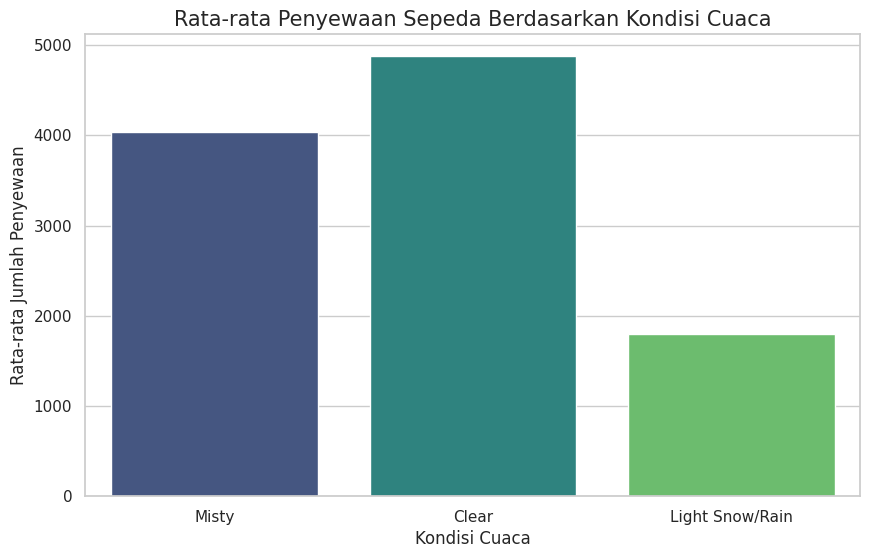

In [42]:
plt.figure(figsize=(10, 6))

sns.barplot(
    x='weather_condition',
    y='total_count',
    data=day_df,
    palette='viridis',
    estimator='mean',
    errorbar=None
)

plt.title('Rata-rata Penyewaan Sepeda Berdasarkan Kondisi Cuaca', fontsize=15)
plt.xlabel('Kondisi Cuaca', fontsize=12)
plt.ylabel('Rata-rata Jumlah Penyewaan', fontsize=12)

plt.show()

### Pertanyaan 2:

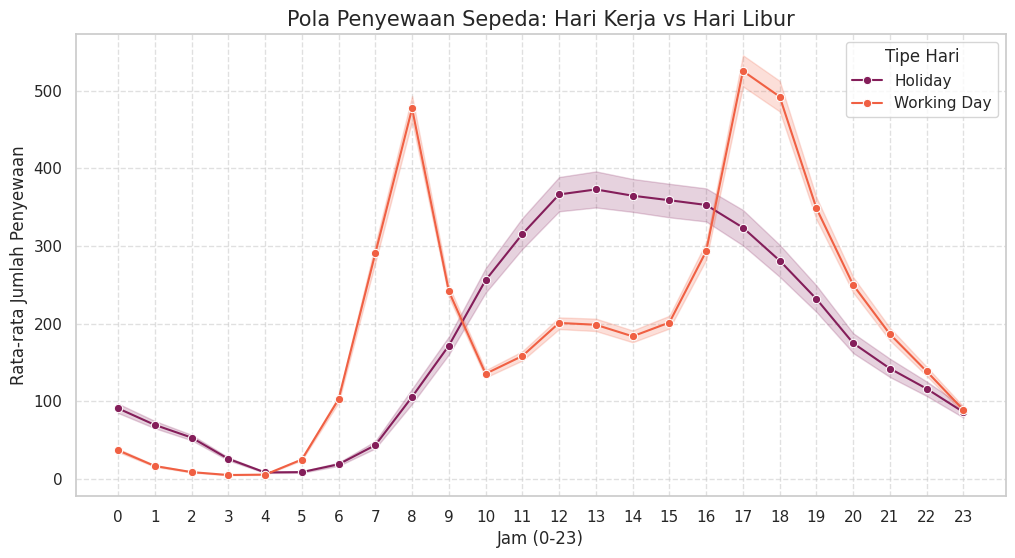

In [43]:
plt.figure(figsize=(12, 6))

sns.lineplot(
    data=hour_df,
    x='hour',
    y='total_count',
    hue='workingday',
    palette='rocket',
    marker='o'
)

plt.title('Pola Penyewaan Sepeda: Hari Kerja vs Hari Libur', fontsize=15)
plt.xlabel('Jam (0-23)', fontsize=12)
plt.ylabel('Rata-rata Jumlah Penyewaan', fontsize=12)
plt.xticks(range(0, 24))
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(title='Tipe Hari')

plt.show()

## Conclusion & Recommendation

- **Conclusion pertanyaan 1:** Kondisi cuaca memiliki pengaruh yang signifikan terhadap jumlah penyewaan sepeda. Berdasarkan rata-rata data:

Cuaca cerah: ± 4876 rental/hari (tertinggi)
Cuaca berawan/mendung: ± 4035 rental/hari
Cuaca hujan ringan/buruk: ± 1803 rental/hari (terendah)

Terlihat adanya penurunan yang cukup drastis ketika kondisi cuaca memburuk. Hal ini menunjukkan bahwa pengguna cenderung lebih aktif menyewa sepeda saat cuaca mendukung, sehingga cuaca menjadi faktor utama dalam menentukan tingkat penggunaan sepeda.

- **Conclusion pertanyaan 2:** Terdapat pola penggunaan sepeda yang jelas berdasarkan jam dalam sehari. Rata-rata penyewaan menunjukkan dua puncak utama:

Pagi hari (07.00–09.00): ± 250–280 rental/jam
Sore hari (17.00–19.00): ± 300–330 rental/jam (puncak tertinggi)

Di luar jam tersebut, jumlah penyewaan cenderung lebih rendah.

Pola ini menunjukkan bahwa penggunaan sepeda didominasi oleh aktivitas commuting (perjalanan kerja/sekolah), dengan intensitas tertinggi pada jam berangkat dan pulang kerja.

- **Recommendation pertanyaan 1:** Berdasarkan pengaruh kondisi cuaca terhadap jumlah penyewaan sepeda, penyedia layanan disarankan untuk meningkatkan ketersediaan sepeda dan kesiapan operasional pada kondisi cuaca cerah karena permintaan cenderung tinggi. Sebaliknya, pada kondisi cuaca buruk, strategi promosi seperti diskon atau insentif dapat diterapkan untuk menjaga tingkat penggunaan. Selain itu, perencanaan operasional seperti penjadwalan maintenance dapat dilakukan saat cuaca buruk karena permintaan relatif lebih rendah.

- **Recommendation pertanyaan 2:** Berdasarkan pola tersebut, penyedia layanan disarankan untuk meningkatkan ketersediaan sepeda pada jam sibuk, yaitu pagi dan sore hari di hari kerja serta siang hari di akhir pekan. Selain itu, strategi promosi dapat difokuskan pada jam-jam sepi untuk meningkatkan penggunaan secara lebih merata.

**Rekomendasi Action Item:**
- Menambah jumlah sepeda dan memastikan ketersediaan unit pada jam sibuk (pagi dan sore hari) untuk memenuhi permintaan pengguna.

- Mengurangi distribusi sepeda pada kondisi cuaca buruk untuk efisiensi operasional, serta mempertimbangkan pemberian insentif atau promo untuk menjaga penggunaan.

- Melakukan perawatan (maintenance) sepeda di luar jam sibuk agar tidak mengganggu operasional saat permintaan tinggi.

- Membuat program promosi pada waktu atau kondisi dengan permintaan rendah (misalnya siang hari atau saat cuaca kurang mendukung) untuk meningkatkan jumlah pengguna.


In [ ]:
day_df.to_csv('main_data.csv', index=False)